In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
timestamps = np.load("timestamps.npy")
power_total = np.load("power_total.npy")
phase_times = np.load("phase_times.npy")
phase_labels = np.load("phase_labels.npy", allow_pickle=True)

In [3]:
def compute_phase_stats(timestamps, power, phase_times, phase_labels):
    results = {}

    phase_names = sorted(set(lbl.rsplit("_", 1)[0] for lbl in phase_labels))

    for phase in phase_names:
        start_tag = phase + "_s"
        end_tag = phase + "_e"

        starts = phase_times[phase_labels == start_tag]
        ends = phase_times[phase_labels == end_tag]

        phase_power_values = []
        total_energy = 0.0
        total_duration = 0.0

        for s, e in zip(starts, ends):
            s += 4 # warm-up
            if e <= s:
                continue

            mask = (timestamps >= s ) & (timestamps < e)
            if not np.any(mask):
                continue

            t_segment = timestamps[mask]
            p_segment = power[mask]

            phase_power_values.append(p_segment)

            energy = np.trapz(p_segment, t_segment)
            total_energy += energy
            total_duration += (e - s)

        if not phase_power_values:
            continue

        vals = np.concatenate(phase_power_values)

        results[phase] = {
            "samples": len(vals),
            "mean_W": float(vals.mean()),
            "std_W": float(vals.std()),
            "min_W": float(vals.min()),
            "max_W": float(vals.max()),
            "p5_W": float(np.percentile(vals, 5)),
            "p95_W": float(np.percentile(vals, 95)),
            "total_energy_J": float(total_energy),
            "duration_s": float(total_duration),
            "avg_power_from_energy_W": float(total_energy / total_duration) if total_duration > 0 else None,
        }

    return results

stats = compute_phase_stats(
    timestamps,
    power_total,
    phase_times,
    phase_labels
)

df = (
    pd.DataFrame.from_dict(stats, orient="index")
    .reset_index()
    .rename(columns={"index": "phase"})
)

df

/tmp/ipykernel_123356/1643609416.py:31: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy = np.trapz(p_segment, t_segment)


,phase,samples,mean_W,std_W,min_W,max_W,p5_W,p95_W,total_energy_J,duration_s,avg_power_from_energy_W
0,eval,489,315.672546,1.725225,311.447998,319.432983,313.323975,317.966980,7735.735352,24.533295,315.315796
1,mllm,1115,556.127686,37.349049,466.255005,580.440002,469.372009,578.548950,31232.964844,56.221329,555.535889
2,pretrain,1270,663.490234,38.874504,470.067017,680.360962,563.528992,678.364014,42253.574219,63.726383,663.046814
3,sft,1027,658.910522,28.791853,555.988037,674.156006,562.396973,671.546021,33905.593750,51.502464,658.329529


In [4]:
def plot_power_with_phases(times, total_power, phase_times, phase_labels, title):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(times, total_power, linewidth=1.0)

    phase_colors = {
        "pretrain": (0.2, 0.8, 0.2, 0.10),
        "sft": (0.2, 0.2, 0.9, 0.10),
        "mllm": (0.9, 0.2, 0.2, 0.10),
        "eval": (0.9, 0.6, 0.2, 0.10),
    }

    def base(lbl):
        return lbl.rsplit("_", 1)[0]

    i = 0
    shown = set()
    while i + 1 < len(phase_labels):
        ls = phase_labels[i]
        le = phase_labels[i + 1]
        ts = phase_times[i]
        te = phase_times[i + 1]
        if ls.endswith("_s") and le.endswith("_e") and base(ls) == base(le) and te > ts:
            name = base(ls)
            color = phase_colors.get(name, (0.5, 0.5, 0.5, 0.08))
            label = name if name not in shown else None
            ax.axvspan(ts, te, color=color, label=label)
            shown.add(name)
            i += 2
        else:
            i += 1

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Total GPU Power (W)")
    ax.set_title(title)
    if shown:
        ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()


def _to_numpy_power(power_samples):
    p = np.array(power_samples, dtype=np.float32)
    if p.ndim == 1:
        p_mat = p.reshape(-1, 1)
        p_total = p
    elif p.ndim == 2:
        p_mat = p
        p_total = p.sum(axis=1)
    else:
        raise ValueError(f"Unexpected power_samples shape: {p.shape}")
    return p_mat, p_total

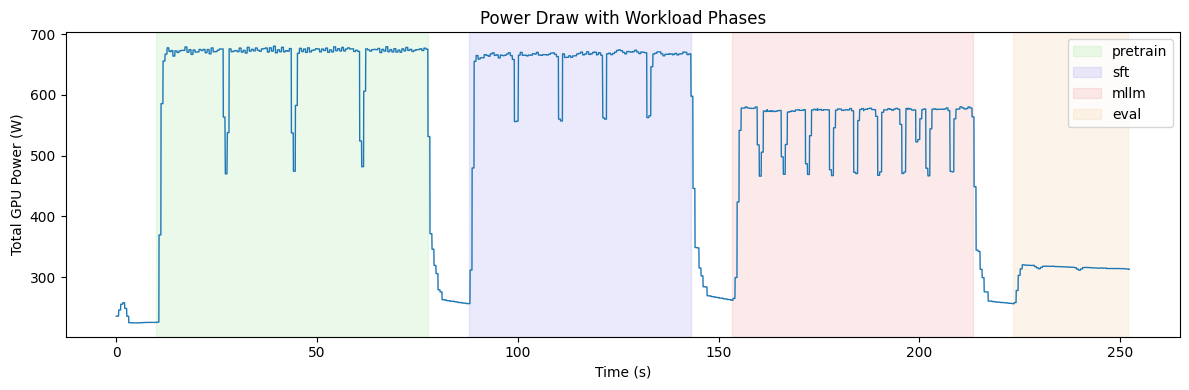

In [5]:
times = np.array(timestamps, dtype=np.float32)
phase_t = np.array(phase_times, dtype=np.float32)
phase_l = np.array(phase_labels, dtype=object)
plot_power_with_phases(
    times=times,
    total_power=power_total,
    phase_times=phase_t,
    phase_labels=phase_l,
    title="Power Draw with Workload Phases"
)


Pretrain  
Model in case: bert-base-uncased (Transformer encoder)  
SFT  
Model in case: gpt2 (CausalLM)  
MLLM  
Model in case: Salesforce/blip2-opt-2.7b (Vision-to-Text，multimodal)  
Eval  
Model in case: gpt2 (Autoregressive Decoding)  
mean: pretrain ≈ sft >> mllm >> eval (actual situation may be pretrain > sft)  
std: pretrain ≈ mllm >> sft >> eval